In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics  import accuracy_score , precision_score , recall_score , f1_score , confusion_matrix , classification_report ,roc_curve , roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier




In [2]:
df = pd.read_csv('C:\\Datasets\\Telco_Customer_Churn\\WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'] , errors = 'coerce')

In [7]:
df['TotalCharges'].dtypes

dtype('float64')

In [8]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [9]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [10]:
df['TotalCharges'].isnull().sum()

np.int64(0)

In [11]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [12]:
df['Churn'].value_counts(normalize = True)*100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

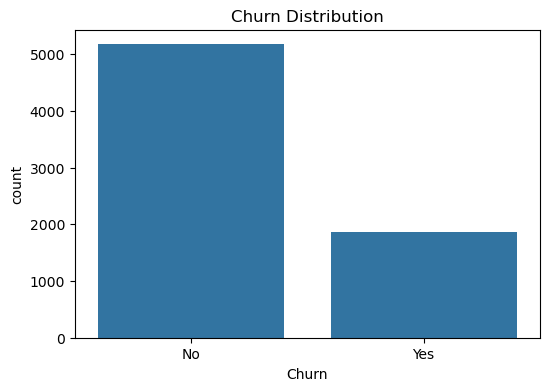

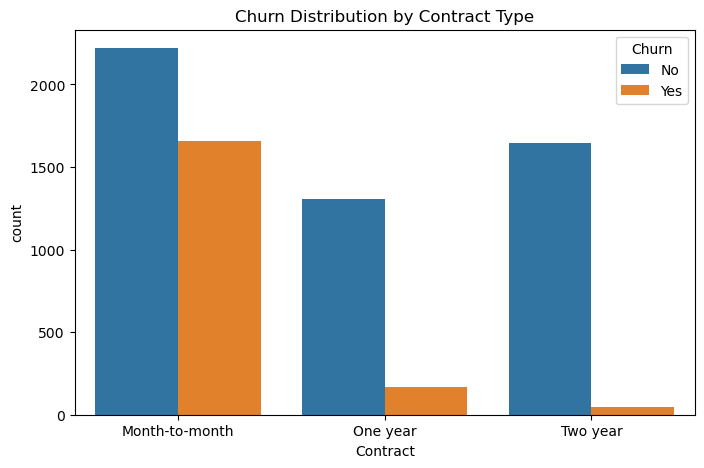

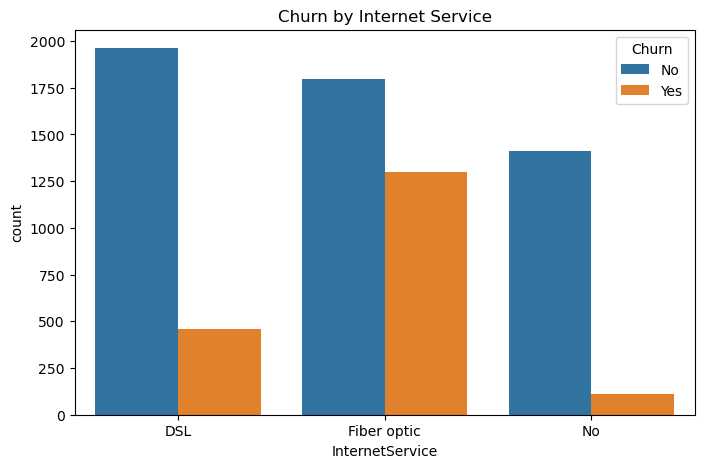

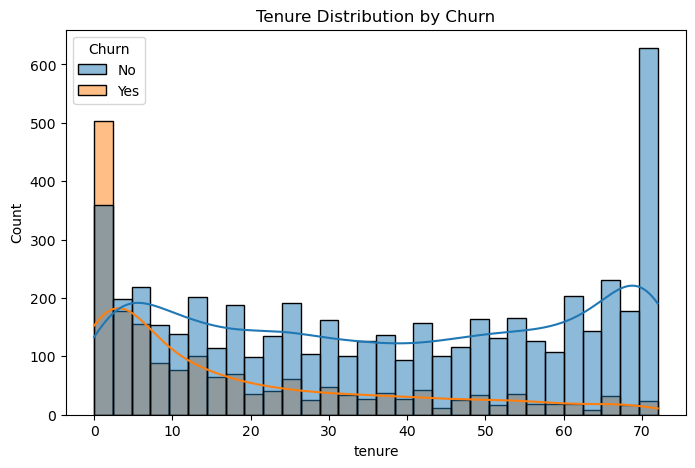

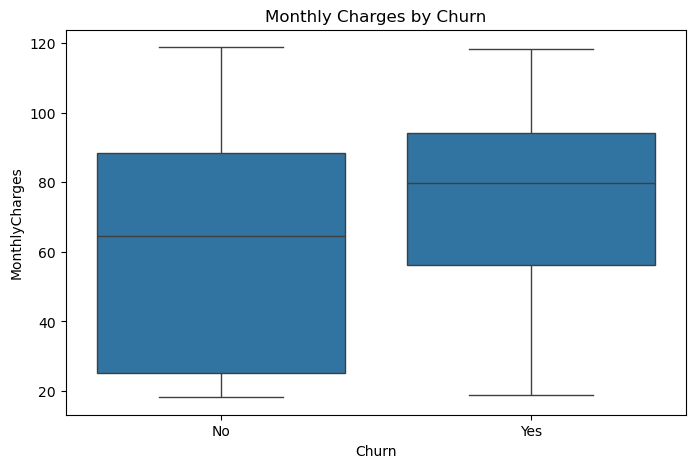

In [13]:
df_eda = df.copy()

plt.figure(figsize = (6, 4))
sns.countplot(data= df_eda , x = 'Churn' )
plt.title('Churn Distribution')
plt.show()

plt.figure(figsize = (8, 5))
sns.countplot(data = df_eda , x ='Contract' , hue = 'Churn')
plt.title('Churn Distribution by Contract Type')
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(data=df_eda, x='InternetService', hue='Churn')
plt.title('Churn by Internet Service')
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(data=df_eda, x='tenure', hue='Churn', bins=30, kde=True)
plt.title('Tenure Distribution by Churn')
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(data=df_eda, x='Churn', y='MonthlyCharges')
plt.title('Monthly Charges by Churn')
plt.show()

In [14]:
df = df.drop('customerID' , axis = 1)

In [15]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [16]:
for col in df.select_dtypes(include = 'object').columns:
    print(col, ':' ,  df[col].nunique())

gender : 2
Partner : 2
Dependents : 2
PhoneService : 2
MultipleLines : 3
InternetService : 3
OnlineSecurity : 3
OnlineBackup : 3
DeviceProtection : 3
TechSupport : 3
StreamingTV : 3
StreamingMovies : 3
Contract : 3
PaperlessBilling : 2
PaymentMethod : 4
Churn : 2


In [17]:
binary_cols = ['Partner' , 'Dependents' , 'PhoneService' , 'PaperlessBilling' , 'Churn']

for col in binary_cols:
    df[col] = df[col].map({'Yes' :1 , 'No' : 0})

df['gender'] = df['gender'].map({'Male' :1 , 'Female' : 0})

multi_cols = ['MultipleLines' , 'InternetService' , 'OnlineSecurity' , 'OnlineBackup' , 'DeviceProtection' , 'TechSupport' , 'StreamingTV' , 'StreamingMovies' , 'Contract' , 'PaymentMethod']

df = pd.get_dummies(df ,columns = multi_cols , drop_first = True)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7043 non-null   float64
 9   Churn                                  7043 non-null   int64  
 10  MultipleLines_No phone service         7043 non-null   bool   
 11  Mult

In [19]:
df.columns = [col[0] .upper() + col[1:] for col in df.columns]

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   Tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7043 non-null   float64
 9   Churn                                  7043 non-null   int64  
 10  MultipleLines_No phone service         7043 non-null   bool   
 11  Mult

In [21]:
X = df.drop('Churn' , axis  = 1)
y = df['Churn']

In [22]:
X_train , X_test , y_train , y_test = train_test_split(X,y , test_size = 0.2 , random_state = 42 , stratify = y)

In [23]:
from sklearn.preprocessing import StandardScaler

Scaler = StandardScaler()
num_cols = ['Tenure' , 'MonthlyCharges' , 'TotalCharges']

X_train[num_cols] = Scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = Scaler.transform(X_test[num_cols])

In [24]:
model = LogisticRegression(max_iter = 1000 , class_weight = 'balanced')
model.fit(X_train , y_train)

y_pred = model.predict(X_test)

In [25]:
print(confusion_matrix(y_test , y_pred))
print(classification_report(y_test , y_pred))

[[747 288]
 [ 81 293]]
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [26]:
rf_model = RandomForestClassifier(class_weight = 'balanced' , n_estimators = 100 , random_state = 42)
rf_model.fit(X_train , y_train)

y_pred_rf = rf_model.predict(X_test)

print(confusion_matrix(y_test , y_pred_rf))
print(classification_report(y_test , y_pred_rf))

[[932 103]
 [192 182]]
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [27]:
xgb_model = XGBClassifier(n_estimators = 100 , random_state = 42 , scale_pos_weight = 3 ,eval_metric = 'logloss')
xgb_model.fit(X_train , y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test , y_pred_xgb))
print(classification_report(y_test , y_pred_xgb))

[[811 224]
 [111 263]]
              precision    recall  f1-score   support

           0       0.88      0.78      0.83      1035
           1       0.54      0.70      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.76      0.77      1409



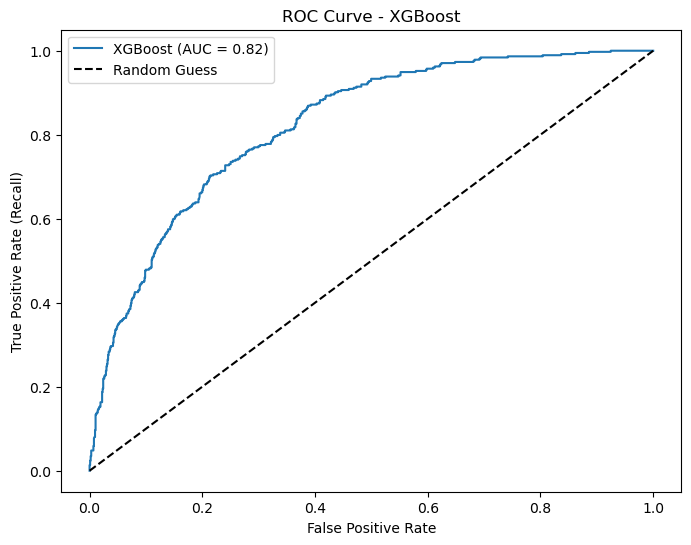

In [28]:
fpr , tpr , thresholds = roc_curve(y_test , y_prob_xgb)
auc = roc_auc_score(y_test , y_prob_xgb)

plt.figure(figsize =(8,6))
plt.plot(fpr , tpr ,label = f'XGBoost (AUC = {auc:.2f})')
plt.plot([0,1] , [0,1] , 'k--' , label = 'Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve - XGBoost')
plt.legend()
plt.show()

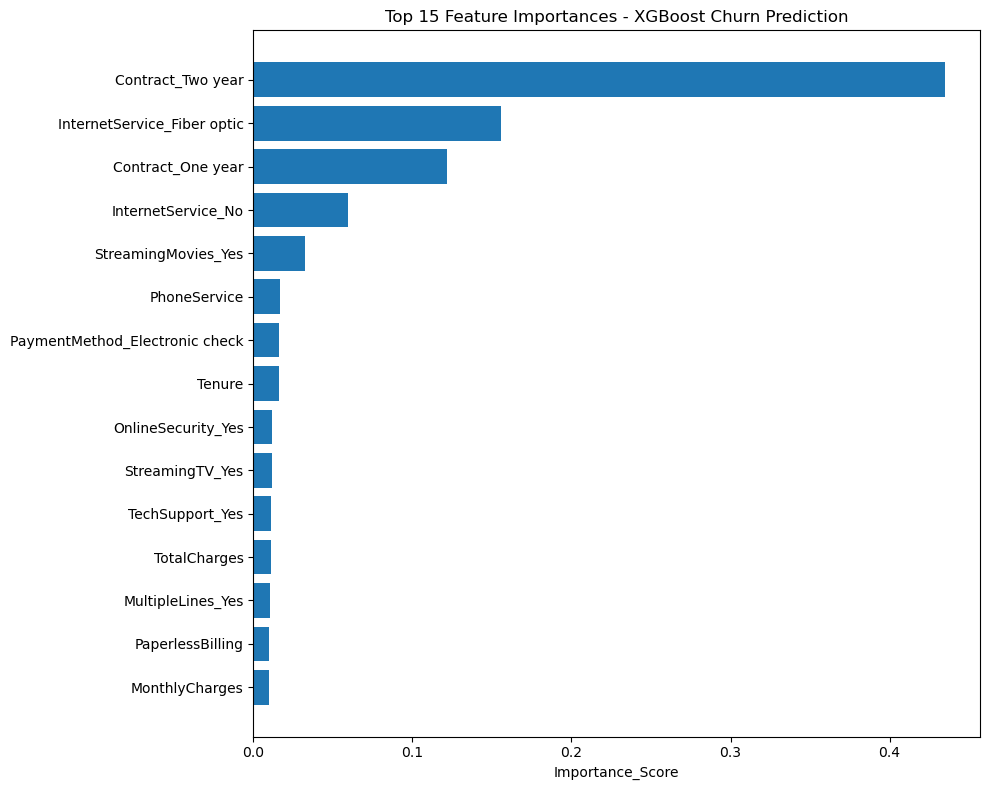

                           Feature  Importance
26               Contract_Two year    0.435106
11     InternetService_Fiber optic    0.155765
25               Contract_One year    0.121984
12              InternetService_No    0.059508
24             StreamingMovies_Yes    0.032195
5                     PhoneService    0.016524
28  PaymentMethod_Electronic check    0.016321
4                           Tenure    0.016089
14              OnlineSecurity_Yes    0.012024
22                 StreamingTV_Yes    0.011687
20                 TechSupport_Yes    0.010914
8                     TotalCharges    0.010897
10               MultipleLines_Yes    0.010267
6                 PaperlessBilling    0.010109
7                   MonthlyCharges    0.010069


In [29]:
feature_importance = pd.DataFrame({
    'Feature' :X_train.columns ,
    'Importance' : xgb_model.feature_importances_
}).sort_values('Importance' , ascending = False)

plt.figure(figsize =(10,8))
plt.barh(feature_importance['Feature'][:15],
         feature_importance['Importance'][:15])
plt.xlabel('Importance_Score')
plt.title('Top 15 Feature Importances - XGBoost Churn Prediction')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(feature_importance.head(15))